# Looking at FATES output

**BEFORE BEGINNING THIS EXERCISE** -  Check that your kernel (upper right corner, above) is `NPL 2023a`. This should be the default kernel, but if it is not, click on that button and select `NPL 2023a`.

_______________
This activity was developed primarily by Adrianna Foster.

## FATES output

While CLM-FATES and regular CLM share many output variables (e.g. `ASA`, `FSR`, `FSH`, etc.), most of the vegetation-related variables are now being simulated, calculated, and output by FATES. The variable names and their structure (as well as the PFTs!) are slightly different from a "big leaf" CLM run.

Here we will show you how to look at some basic FATES output for the global cases you just ran as well as a single-point case which we pre-staged for you.

*As before, start by loading some packages*

In [4]:
# python packages
import os
import glob
import xarray as xr
import numpy as np
import functools

# resources for plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
%matplotlib inline

### Helper functions

These are a few helper functions that we will use in this notebook

In [78]:
def preprocess(data_set: xr.Dataset, data_vars: list[str]) -> xr.Dataset:
    """Preprocesses an xarray Dataset by subsetting to specific variables - to be used on read-in

    Args:
        data_set (xr.Dataset): input Dataset

    Returns:
        xr.Dataset: output Dataset
    """

    return data_set[data_vars]


def annual_sum(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes annual sum

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual sum output
    """

    months = raw_values["time.daysinmonth"]
    return conversion_factor * (months * raw_values).groupby("time.year").sum()


def annual_mean(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes weighted annual mean using daysinmonth for missing-aware inputs.

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual mean output
    """

    months = raw_values["time.daysinmonth"]
    
    # multiply by number of days in month and conversion factor
    weighted = (raw_values * conversion_factor) * months

    # compute number of valid days per year
    valid_days = months.where(raw_values.notnull())

    # group and sum weighted data and valid days
    ann_sum = weighted.groupby("time.year").sum(dim="time", skipna=True)
    days_per_year = valid_days.groupby("time.year").sum(dim="time", skipna=True)

    return ann_sum / days_per_year.where(days_per_year > 0.0)

## 1. Reading and formatting data

**Note**: the drop-down solutions, below, assume you used i.fates.year1.a and i.fates.year1.a_vcmax output for plotting for this section.

### 1.1 Read in the data
The first step is to grab the history files from the runs you completed in the FATES challenge.

For this example we will use:
- gross primary production (`FATES_GPP` and `FATES_GPP_PF`), 
- latent heat flux (`EFLX_LH_TOT`), and
- sensible heat flux (`FSH`)

<b>NOTE:</b> These are the raw history files that CTSM writes out. 

By default, they include grid cell averaged monthly means for different state and flux variables.

<div class="alert alert-block alert-info">
    <b>TIP:</b> If you want to look at other variables, the <b>data_vars_glob</b> variable in the cell below is where you can modify what we're reading off of the CLM history files.
</div>

#### Printing information about the dataset is helpful for understanding your data. 
- *What dimensions do your data have?*
- *What are the coordinate variables?*
- *What variables are we looking at?*
- *Is there other helpful information, or are there attributes in the dataset we should be aware of?*


In [6]:
# note: change the user here to your user name
user = 'afoster'

# this should be the history directory for the control directory and the one with vcmax updated
control_hist = f"/glade/derecho/scratch/{user}/archive/i.fates.year1.a/lnd/hist"
vcmax_hist = f"/glade/derecho/scratch/{user}/archive/i.fates.year1.a_vcmax/lnd/hist"

# create path to all files, including unix wild card for all dates
control_files = sorted(glob.glob(os.path.join(control_hist, "i.fates.year1.a.clm2.h0a.*")))
vcmax_files = sorted(glob.glob(os.path.join(vcmax_hist, "i.fates.year1.a_vcmax.clm2.h0a.*")))

# read in files as xarray datasets:
data_vars_glob = ['FATES_GPP', 'FATES_GPP_PF', 'EFLX_LH_TOT', 'FSH',
                  'FATES_FRACTION', 'area', 'landfrac']

ds_control = xr.open_mfdataset(
    control_files,
    preprocess=functools.partial(preprocess, data_vars=data_vars_glob)
)
ds_vcmax = xr.open_mfdataset(
    vcmax_files, 
    preprocess=functools.partial(preprocess, data_vars=data_vars_glob)
)

In [7]:
# print information about one of the datasets
ds_control

<xarray.Dataset>
Dimensions:         (time: 12, lat: 96, lon: 144, fates_levpft: 14)
Coordinates:
  * fates_levpft    (fates_levpft) int32 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * time            (time) object 2000-01-16 12:00:00 ... 2000-12-16 12:00:00
  * lon             (lon) float32 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat             (lat) float32 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
Data variables:
    FATES_GPP       (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FATES_GPP_PF    (time, fates_levpft, lat, lon) float32 dask.array<chunksize=(1, 14, 96, 144), meta=np.ndarray>
    EFLX_LH_TOT     (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FSH             (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    FATES_FRACTION  (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    area            (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    landfrac        (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
Attributes: (12/36)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 06/25/26 04:33:40
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_roof:                     71
    ctype_urban_sunwall:                  72
    ctype_urban_shadewall:                73
    ctype_urban_impervious_road:          74
    ctype_urban_pervious_road:            75
    time_period_freq:                     month_1

You can also print information about the variables in your dataset. The example below prints information about one of the data variables we read in. You can modify this cell to look at some of the other variables in the dataset.

*What are the units, long name, and dimensions of your data?*

In [8]:
ds_control.FATES_GPP_PF

<xarray.DataArray 'FATES_GPP_PF' (time: 12, fates_levpft: 14, lat: 96, lon: 144)>
dask.array<concatenate, shape=(12, 14, 96, 144), dtype=float32, chunksize=(1, 14, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * time          (time) object 2000-01-16 12:00:00 ... 2000-12-16 12:00:00
  * lon           (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat           (lat) float32 -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Attributes:
    long_name:      total PFT-level GPP in kg carbon per m2 land area per second
    units:          kg m-2 s-1
    cell_methods:   time: mean
    landunit_mask:  unknown

## 1.2 Simple Calculations
To begin with, we need to modify all `FATES_` variables by multiplying them by `FATES_FRACTION`. This is because the FATES model doesn't know how much of each gridcell is occupied by natural vegetation, and so the grid-cell averaging assumings all of it is. We need to correct for this by multiplying by the variable `FATES_FRACTION`:

In [9]:
ds_control['GPP'] = ds_control.FATES_GPP*ds_control.FATES_FRACTION
ds_control['GPP'].attrs = ds_control.FATES_GPP.attrs

ds_control['GPP_PF'] = ds_control.FATES_GPP_PF*ds_control.FATES_FRACTION
ds_control['GPP_PF'].attrs = ds_control.FATES_GPP_PF.attrs

ds_vcmax['GPP'] = ds_vcmax.FATES_GPP*ds_vcmax.FATES_FRACTION
ds_vcmax['GPP'].attrs = ds_vcmax.FATES_GPP.attrs

ds_vcmax['GPP_PF'] = ds_vcmax.FATES_GPP_PF*ds_vcmax.FATES_FRACTION
ds_vcmax['GPP_PF'].attrs = ds_vcmax.FATES_GPP_PF.attrs

---
## 2. Plotting
### 2.1 Easy plots using Xarray
To get a first look at the data, we can plot a month of data from the simulation, selecting the month using the `.isel` function.

<div class="alert alert-block alert-info">
    <b>NOTE:</b> The plotting function only works with 1D or 2D data. Our data are 3D (time, lat, lon), so we need to specify a specific value for the other variables. Below, we select a specific time using the <i>isel</i>, leaving the lat and lon dimensions to plot on the x and y axes.
</div>

- We will plot GPP (variable = `GPP`). Note that we select the variable by specifying our dataset, `ds_control`, and the variable. 
- The plot is for the first year of data (`time=slice(0, 12)`)
- This plotting function will plot `GPP` for each simulation in our dataset

*More plotting examples are on the [xarray web site](https://docs.xarray.dev/en/latest/user-guide/plotting.html)*

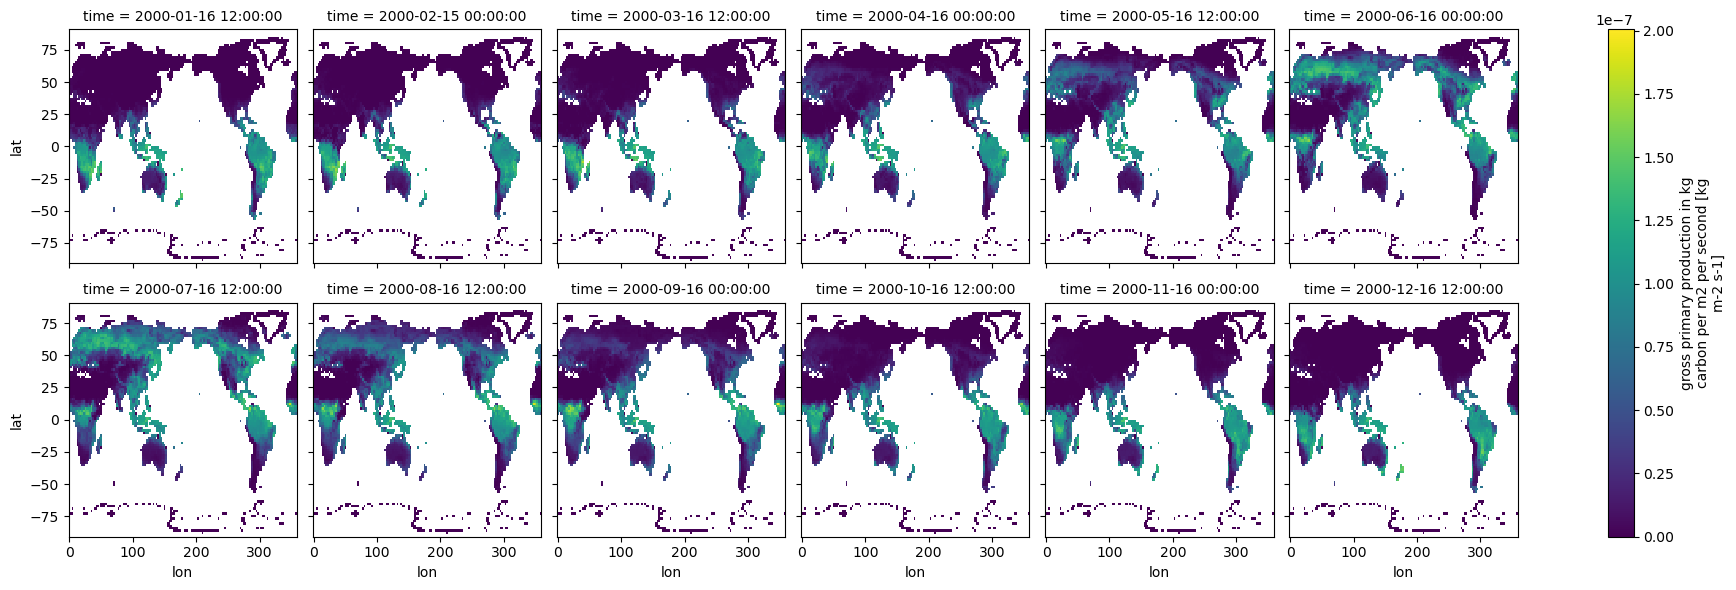

In [10]:
ds_control.GPP.isel(time=slice(0, 12)).plot(x='lon', y='lat', col="time", col_wrap=6);

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_plot_1.png)

*<p style="text-align: left;"> Figure: Plotting solution for monthly GPP for our control simulation. </p>*
    
</details>
</div>

**Question:** 

What do you notice in the Northern Hemisphere over the course of the year?

### 2.2 Calculating differences

We can calculate the differences between our control run with FATES and the one in which we updated the vcmax parameter for PFT 1.
- Calculates annual GPP for both simulations
- Defines the difference as a new variable, `gpp_diff`

In [12]:
gpp_cf = 24*60*60 # kgC/m2/yr

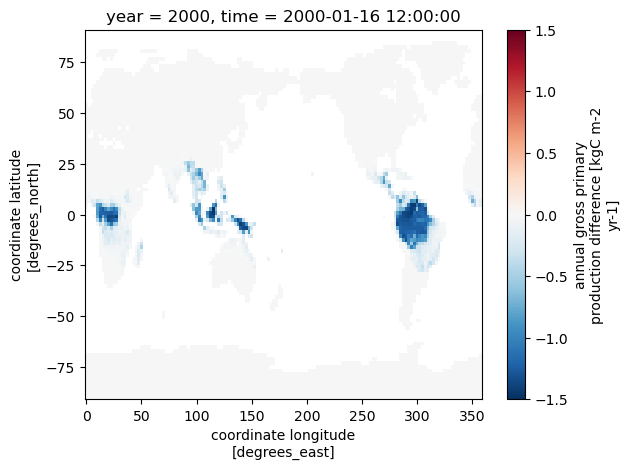

In [46]:
gpp_ann_control = annual_sum(ds_control.GPP, gpp_cf)*ds_control.landfrac.isel(time=0)
gpp_ann_vcmax = annual_sum(ds_vcmax.GPP, gpp_cf)*ds_vcmax.landfrac.isel(time=0)
gpp_diff = gpp_ann_vcmax - gpp_ann_control
gpp_diff.attrs = {'units': 'kgC m-2 yr-1', 'long_name': 'annual gross primary production difference'}
gpp_diff.plot(cmap='RdBu_r', vmin=-1.5, vmax=1.5);
plt.savefig('../../../images/diagnostics/clm_ctsm/fates_plot_2.png', bbox_inches='tight')

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_plot_2.png)

*<p style="text-align: left;"> Figure: Plotting solution for annual GPP for our updated solution minus the control simulation. </p>*
    
</details>
</div>

**Questions:** 
- How is GPP different for our updated simulation, relative to the control simulation?
- Where are the differences the largest?
- Where are they absent?
- **What is causing these GPP changes** in different regions and why is it only in some areas?

#### Do the differences affect all PFTs?
To find out, we can plot the `GPP_PF` variable, which is indexed by PFT.

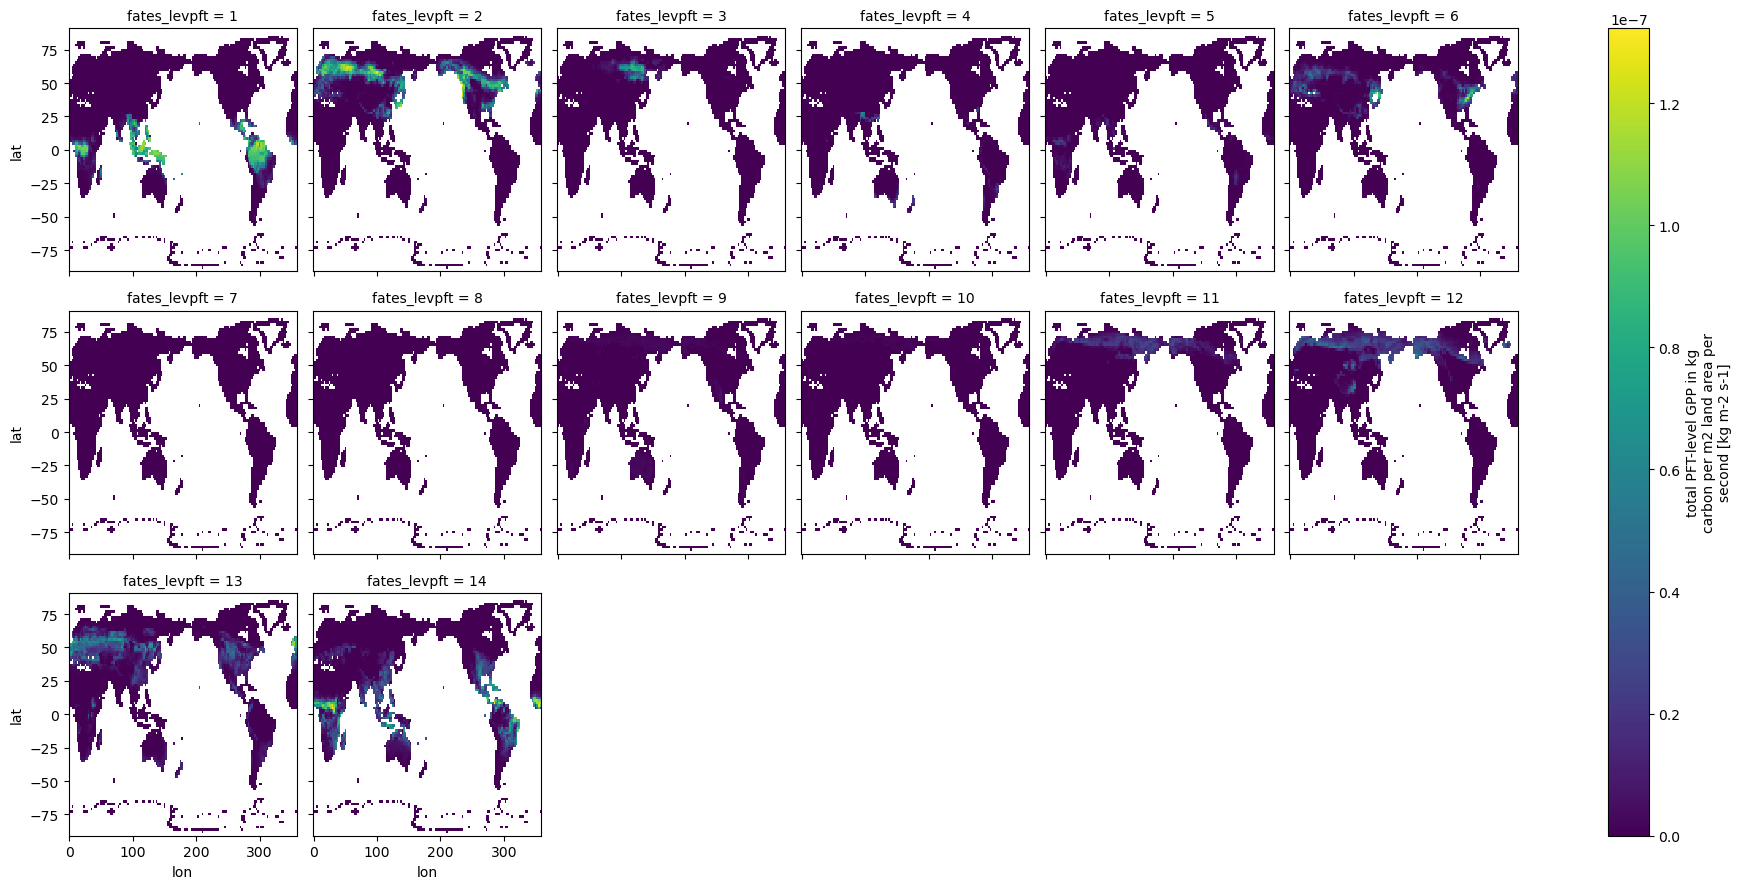

In [34]:
ds_control.GPP_PF.isel(time=5).plot(x='lon', y='lat', col="fates_levpft", col_wrap=6);

#### Do the differences
To find out, do the same calculation as above, but with the `GPP_PF` variable.

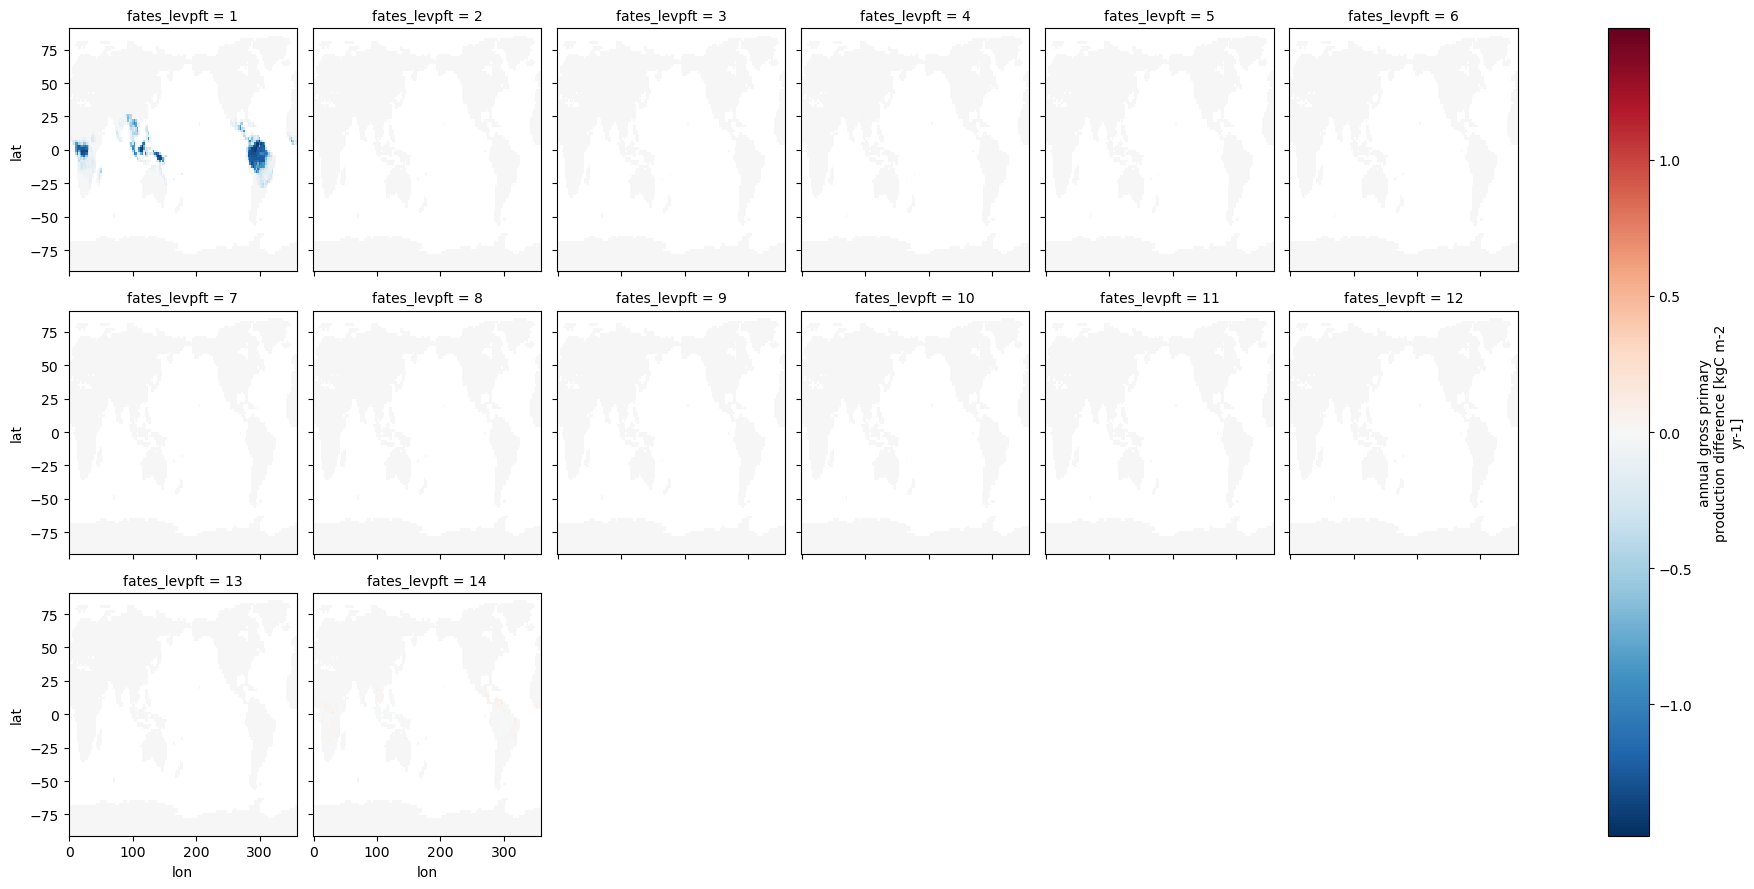

In [65]:
gpp_ann_control_pf = annual_sum(ds_control.GPP_PF, gpp_cf)*ds_control.landfrac.isel(time=0)
gpp_ann_vcmax_pf = annual_sum(ds_vcmax.GPP_PF, gpp_cf)*ds_vcmax.landfrac.isel(time=0)
gpp_diff_pf = gpp_ann_vcmax_pf - gpp_ann_control_pf
gpp_diff_pf.attrs = {'units': 'kgC m-2 yr-1', 'long_name': 'annual gross primary production difference'}
gpp_diff_pf.plot(x='lon', y='lat', col="fates_levpft", col_wrap=6)
plt.savefig('../../../images/diagnostics/clm_ctsm/fates_plot_3.png', bbox_inches='tight')

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_plot_3.png)

*<p style="text-align: left;"> Figure: Plotting solution for comparing GPP by PFT for our updated simulation from our control. </p>*
    
</details>
</div>

**Questions:**
- Which PFT(s) show any difference? Why is this?

*<b>Hint</b>: you can check the `fates_pftname` variable in `/glade/u/home/$USER/code/my_cesm_code/CTSM/src/fates/parameter_files/fates_params_default.json` to see which PFT corresponds to which index.*

#### Do the differences affect other variables?
To find out, we can plot `EFLX_LH_TOT`, which is latent heat flux. How do you think this will be affected?

`EFLX_LH_TOT` is a regular CLM variable (that is, it is calculated by CLM, not FATES, so we should not multiply it by `FATES_FRACTION`).

In [48]:
ds_control.EFLX_LH_TOT

<xarray.DataArray 'EFLX_LH_TOT' (time: 12, lat: 96, lon: 144)>
dask.array<concatenate, shape=(12, 96, 144), dtype=float32, chunksize=(1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2000-01-16 12:00:00 ... 2000-12-16 12:00:00
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
Attributes:
    long_name:      total latent heat flux [+ to atm]
    units:          W/m^2
    cell_methods:   time: mean
    landunit_mask:  unknown

#### Do the differences
Let's calculate annual latent heat flux. This time we will use annual mean instead of an annual sum:

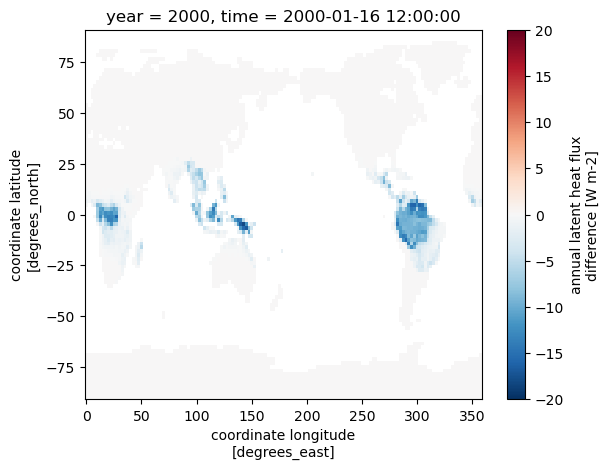

In [80]:
lh_ann_control = annual_mean(ds_control.EFLX_LH_TOT)*ds_control.landfrac.isel(time=0)
lh_ann_vcmax = annual_mean(ds_vcmax.EFLX_LH_TOT)*ds_vcmax.landfrac.isel(time=0)
lh_diff = lh_ann_vcmax - lh_ann_control
lh_diff.attrs = {'units': 'W m-2', 'long_name': 'annual latent heat flux difference'}
lh_diff.plot(vmin=-20, vmax=20, cmap='RdBu_r')
plt.savefig('../../../images/diagnostics/clm_ctsm/fates_plot_4.png', bbox_inches='tight')

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_plot_4.png)

*<p style="text-align: left;"> Figure: Plotting solution for comparing latent heat flux for our updated simulation from our control. </p>*
    
</details>
</div>

**Questions:** 
- How is latent heat flux different?
- Try looking at sensible heat flux (`FSH`). What differences do you see? 

*Note that you might want to change the minimun (`vmin`) and maximum (`vmax`) colorbar values for the plot when you change variables*

<div class="alert alert-block alert-info">
    <b>CHALLENGE:</b> Using what you learned in the previous CLM diagnostics notebook, can you make some of the maps we made above look nicer?
</div>

---
## 3. Investigating vegetation demographics with FATES

As we described above, when run in higher complexity modes (i.e., not SP mode) FATES simulates more than just GPP and other biophysical fluxes. It also simulates vegetation demography (e.g., growth, allocation, competition, mortality, etc.) over time. This means we can look at really interesting outputs like vegetation structure (sizes and PFTs of trees), canopy closure, and successional dynamics.

We have already run a simulation at a NEON site: Bartlett Experimental Forest (**BART**). BART is a terrestrial NEON field site located within the Saco River Valley of the White Mountain National Forest in Carroll County, New Hampshire. Climate and glacial till soil make BART an ideal area for old-growth northern deciduous hardwoods consisting of beech (*Fagus sp.*) and sugar maple (*Acer saccarum*). White pines (*Pinus strobus*) are dispersed throughout the site but are primarily found in lower elevations. Softwood trees such as hemlock (*Tsuga canadensis*), balsam fir (*Abies balsamea*), and spruce are frequently found on cool steep slopes or in lower elevations with poor drainage.

For more information about this site, see the <a href="https://www.neonscience.org/field-sites/bart">NEON webpage</a> for it. 

For this simulation, we ran FATES in full complexity mode, but initialized the model with inventory data from NEON. For information on how to do inventory initialization with FATES, see the <a href='https://fates-users-guide.readthedocs.io/en/latest/user/Model-Initialization-Modes.html'>online documentation</a>.

In [96]:
# read in the dataset as before, but use our pre-staged data
bart_hist_path = "/glade/derecho/scratch/afoster/archive/i.fates.BART/lnd/hist"
bart_files = sorted(glob.glob(os.path.join(bart_hist_path, "i.fates.BART.clm2.h0a.*")))

data_vars_singlept = ['FATES_GPP', 'FATES_VEGC', 'FATES_VEGC_PF',
                      'FATES_GPP_PF', 'FATES_NPLANT_SZ', 'FATES_CANOPYAREA_HT']

ds_bart = xr.open_mfdataset(
    bart_files,
    preprocess=functools.partial(preprocess, data_vars=data_vars_singlept)
).isel(lndgrid=0)

OSError: no files to open

Because this is a single site, and not a regional or global run, we can just grab the one gridcell with `.sel(lndgrid=0)`, and we additionally don't need to multiply any of the FATES variables by `FATES_FRACTION`, because we just assume the gridcell is completely naturally vegetated.

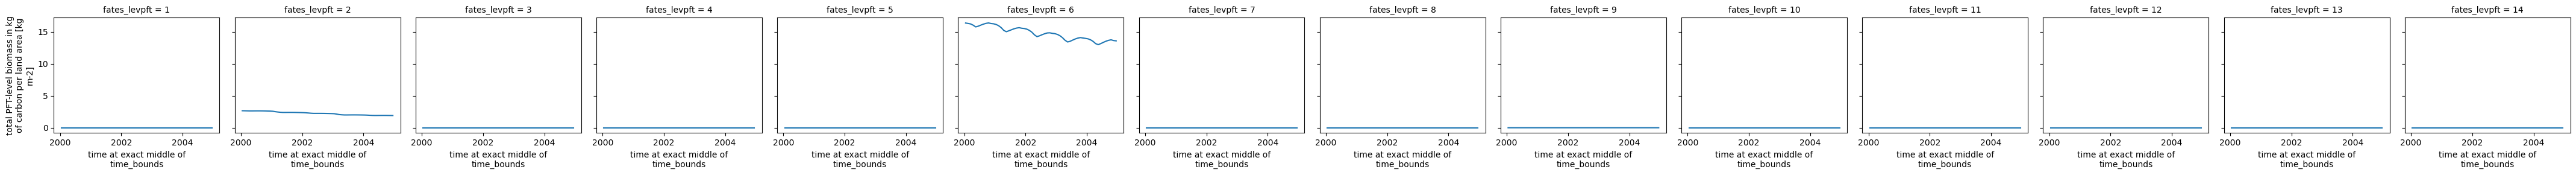

In [95]:
# print information about the dataset
ds_bart.FATES_VEGC_PF.plot(col='fates_levpft')

In [ ]:
point = ds.sel(lon=300, lat=-5, method='nearest')
point.ASA.plot(x='time') ;

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_5.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

Similar to the maps above, there are variations in albedo in the simulation at this location. Let's add other variables to explore why we see differences at this location. 

In [ ]:
plt.figure(figsize=(10,6))
'''this first plot is the same as the one above'''
plt.subplot(221)
point.ASA.plot()
plt.xlabel(None)

'''now we'll look for potential sources of the difference'''
plt.subplot(222)
point.ELAI.plot() 
plt.xlabel(None)

plt.subplot(223)
point.FSDS.plot() 
plt.title(None)

plt.subplot(224)
point.FSR.plot() 
plt.title(None) ;

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_6.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

**Questions:** 
- What variables show differences?
- What variables are similar?
- How do the differences and similarities help to explain the differences in albedo?

#### 2.3.2 Global time series
There are many reasons why we may want to calculate globally integrated time series for particular variables.
This requires weighting the values from each grid cell by the total land area of individual grid cells. The example below does this for our dataset. 

#### First calculate the land weights:
- land area `la` that is the product of land fraction (fraction of land area in each grid cell) and the total area of the grid cell (which changes by latitude). Units are the same as area.
- land weights `lw`, the fractional weight that each grid makes to the global total, is calculated as the land area of each grid cell divided by the global sum of the land area.

The land weights are shown in the plot below. Note that these are larger near the equator, and smaller at the poles and along the coastline

In [ ]:
la = (ds.landfrac*ds.area).isel(time=0).drop(['time']) 
la = la * 1e6  #converts from land area from km2 to m2 
la.attrs['units'] = 'm^2'
lw = la/la.sum()
lw.plot() ;

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_7.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

#### Next, calculate and plot a global weighted sum
<div class="alert alert-block alert-info">

<b>NOTE:</b>  You will likely want to calculate global weighted sum for a variety of different variables. For variables that have area-based units (e.g. GPP, gC/<b>m^2</b>/s), you need to use the land area variable when calculating a global sum. <b> Remember to pay attention to the units and apply any necessary conversions!</b> Keep in mind that grid cell area is reported in km^2. 

</div>


In [ ]:
dsGlobalWgt = (ds * lw).sum(['lat','lon'])

plt.figure(figsize=(12,5))
plotVars = ['ASA','FSDS','ELAI','FSR']
for i in range(len(plotVars)):
    # First add metadata for plotting
    dsGlobalWgt[plotVars[i]].attrs['long_name'] = ds[plotVars[i]].attrs['long_name']
    dsGlobalWgt[plotVars[i]].attrs['units'] = ds[plotVars[i]].attrs['units']

    # then make plots
    plt.subplot(2,2,(i+1))
    dsGlobalWgt[plotVars[i]].plot()
    
    if i == 0:
        plt.title('Weighted global sum',loc='left', fontsize='large', fontweight='bold')
        
    if i<2:
        plt.xlabel(None)

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_8.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

---
### 2.4 Calculate an annual weighted mean and create customized plots
Annual averages require a different kind of weighting: the number of days per month.
This example creates python functions that allow you to easily calculate annual averages and create customized plots. 

<div class="alert alert-block alert-info">

<b>Python functions:</b> In python, creating a function allows us to use the same calculation numerous times instead of writing the same code repeatedly.
</div>


#### 2.4.1 Calculate monthly weights
The below code creates a function `weighted_annual_mean` to calculate monthly weights. Use this function any time you want to calculate weighted annual means.

In [ ]:
# create a function that will calculate an annual mean weighted by days per month
def weighted_annual_mean(array):
    mon_day  = xr.DataArray(np.array([31,28,31,30,31,30,31,31,30,31,30,31]), dims=['month'])
    mon_wgt  = mon_day/mon_day.sum()
    return (array.rolling(time=12, center=False) # rolling
            .construct("month") # construct the array
            .isel(time=slice(11, None, 12)) # slice so that the first element is [1..12], second is [13..24]
            .dot(mon_wgt, dims=["month"]))

# generate annual means
for i in range(len(plotVars)):
    temp = weighted_annual_mean(
        ds[plotVars[i]].chunk({"time": 12}))
    
    if i ==0:
        dsAnn = temp.to_dataset(name=plotVars[i])
    else:
        dsAnn[plotVars[i]] = temp

# Make a simple plot
dsAnn.isel(time=0).ELAI.plot(x='lon',y='lat',robust=True) ;

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_9.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

In [ ]:
dsAnn

#### 2.4.2 Customized maps
Creating a function isn't necessary to plot maps, but this function, which uses python's `cartopy`, allows you to make several pretty maps in one figure.

Additional examples and information are available on the [cartopy website](https://scitools.org.uk/cartopy/docs/v0.15/index.html)

There are two code blocks below. The first block of code defines the function. The second code block creates the plot. 

In [ ]:
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import copy

# Generate a function for making panel plots of maps
## many of these features are not required, but provide additional control over plotting
def map_function(da, cb=0, cmap='viridis', panel=None,  ax=None, 
                 title=None, vmax=None, vmin=None, units=None,nbins=200):
    '''a function to make one subplot'''
    wrap_data, wrap_lon = add_cyclic_point(da.values, coord=da.lon)

    if ax is None: ax = plt.gca()

    # define the colormap, including the number of bins
    cmap = copy.copy(plt.get_cmap(cmap,nbins))
    im = ax.pcolormesh(wrap_lon,da.lat,wrap_data,
                   transform=ccrs.PlateCarree(),
                   vmax=vmax,vmin=vmin,cmap=cmap)

    # set the bounds of your plot
    ax.set_extent([-180,180,-56,85], crs=ccrs.PlateCarree())

    # add title & panel labels
    ax.set_title(title,loc='left', fontsize='large', fontweight='bold')
    ax.annotate(panel, xy=(0.05, 0.90), xycoords=ax.transAxes,
                ha='center', va='center',fontsize=16)    

    # add plotting features
    ax.coastlines()
    ocean = ax.add_feature(
        cfeature.NaturalEarthFeature('physical','ocean','110m', facecolor='white'))
    
    # control colorbars on each plot & their location
    if cb == 1:
        cbar = fig.colorbar(im, ax=ax,pad=0.02, fraction = 0.03, orientation='horizontal')
        cbar.set_label(units,size=12,fontweight='bold')
    if cb == 2:
        cbar = fig.colorbar(im, ax=ax,pad=0.02, fraction = 0.05, orientation='vertical')    
        cbar.set_label(units,size=12)#,weight='bold')

#### Now make the plot!

In [ ]:
i = 0
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(13,6), constrained_layout=True,
                         subplot_kw=dict(projection=ccrs.Robinson()))
for index, ax in np.ndenumerate(axes):
    if i == 0:
        plotData = dsAnn.ELAI.isel(time=slice(-10,None)).mean('time')
        map_function(plotData, ax=ax,cb=2,
                     panel='(a)', nbins=10,
                     vmax=5,vmin=0,
                     units='Final Annual ELAI')
    if i == 1:
        plotData = (dsAnn.ELAI.isel(time=slice(-10,None)).mean('time')- \
                    dsAnn.ELAI.isel(time=slice(0,10)).mean('time'))
        map_function(plotData, ax=ax,cb=2,panel='(b)',
                     units='Annual ELAI Change, Final-Initial',
                     cmap='bwr',nbins=7,
                     vmax=0.75,vmin=-0.75)    
                     
    i = i+1

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman" color='blue'>Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/basics_plot_10.png)

*<p style="text-align: center;"> Figure: Plotting solution. </p>*
    
</details>
</div>

## Extra credit challenge
If you have extra time & energy, try running through this notebook with other variables. Interesting options could include: 
- Latent heat flux (the sum of `FCTR`+`FCEV`+`FGEV`) or 
- Gross Primary Production (`GPP`) 

<div class="alert alert-block alert-warning">

<b>HINT:</b> pay attention to units for these challenges. 

</div>